In [1]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, n_inputs, learning_rate=0.1):
        self.weights = np.zeros(n_inputs)
        self.bias = 0.0
        self.lr = learning_rate
        self.weight_history = [(self.weights.copy(), self.bias)]

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x):
        z = np.dot(self.weights, x) + self.bias
        return self.activation(z)

    def train(self, X, y, max_epochs=20):
        print(f"Initial weights: {self.weights}, bias: {self.bias}\n")
        update_count = 0
        for epoch in range(max_epochs):
            errors = 0
            for xi, target in zip(X, y):
                pred = self.predict(xi)
                error = target - pred
                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error
                    self.weight_history.append((self.weights.copy(), self.bias))
                    update_count += 1
                    errors += 1
                    print(f"Update {update_count} (Epoch {epoch+1}): "
                          f"input={xi}, target={target}, pred={pred}, "
                          f"weights={self.weights}, bias={self.bias:.2f}")
            if errors == 0:
                print(f"\nConverged after epoch {epoch+1}, total updates: {update_count}")
                return True
        print(f"\nDid NOT converge within {max_epochs} epochs, total updates: {update_count}")
        return False

In [2]:
def plot_decision_boundaries(weight_history, X, y, gate_name, max_plots=None):
    n_features = X.shape[1]
    history = weight_history if max_plots is None else weight_history[:max_plots]

    for idx, (w, b) in enumerate(history):
        plt.figure(figsize=(4, 4))

        # Plot data points
        for xi, target in zip(X, y):
            color = 'blue' if target == 1 else 'red'
            if n_features == 2:
                plt.scatter(xi[0], xi[1], c=color, s=100, edgecolors='black', zorder=3)
            else:  # 1D case (NOT gate)
                plt.scatter(xi[0], 0, c=color, s=100, edgecolors='black', zorder=3)

        if n_features == 2:
            x_vals = np.array([-0.5, 1.5])
            if w[1] != 0:
                y_vals = -(w[0] * x_vals + b) / w[1]
                plt.plot(x_vals, y_vals, 'k-', linewidth=2)
            plt.xlim(-0.5, 1.5)
            plt.ylim(-0.5, 1.5)
            plt.xlabel('x1')
            plt.ylabel('x2')
        else:  # NOT gate: single feature
            if w[0] != 0:
                boundary_x = -b / w[0]
                plt.axvline(x=boundary_x, color='k', linewidth=2)
            plt.xlim(-0.5, 1.5)
            plt.ylim(-1, 1)
            plt.xlabel('x1')

        plt.title(f"{gate_name} Gate - After Update {idx}\nw={np.round(w,2)}, b={b:.2f}")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

AND GATE
Initial weights: [0. 0.], bias: 0.0

Update 1 (Epoch 1): input=[0 0], target=0, pred=1, weights=[0. 0.], bias=-0.10
Update 2 (Epoch 1): input=[1 1], target=1, pred=0, weights=[0.1 0.1], bias=0.00
Update 3 (Epoch 2): input=[0 0], target=0, pred=1, weights=[0.1 0.1], bias=-0.10
Update 4 (Epoch 2): input=[0 1], target=0, pred=1, weights=[0.1 0. ], bias=-0.20
Update 5 (Epoch 2): input=[1 1], target=1, pred=0, weights=[0.2 0.1], bias=-0.10
Update 6 (Epoch 3): input=[0 1], target=0, pred=1, weights=[0.2 0. ], bias=-0.20
Update 7 (Epoch 3): input=[1 0], target=0, pred=1, weights=[0.1 0. ], bias=-0.30
Update 8 (Epoch 3): input=[1 1], target=1, pred=0, weights=[0.2 0.1], bias=-0.20

Converged after epoch 4, total updates: 8


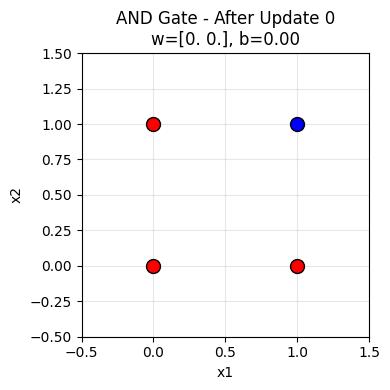

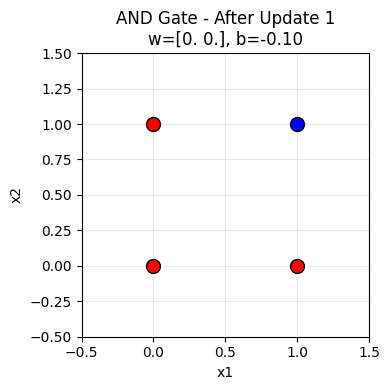

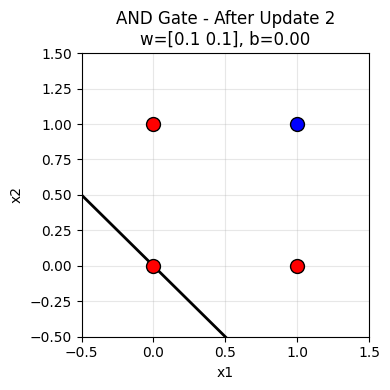

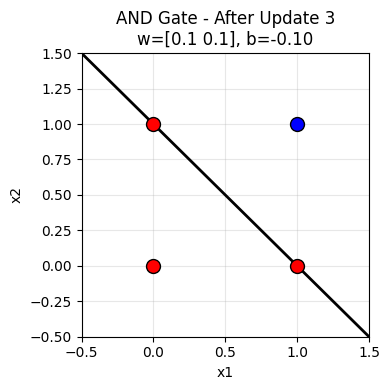

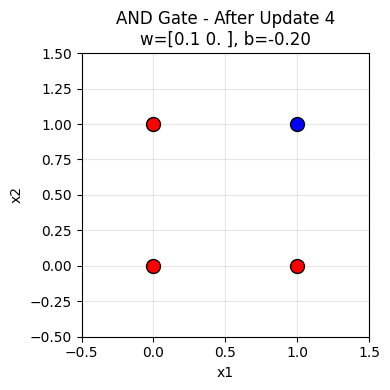

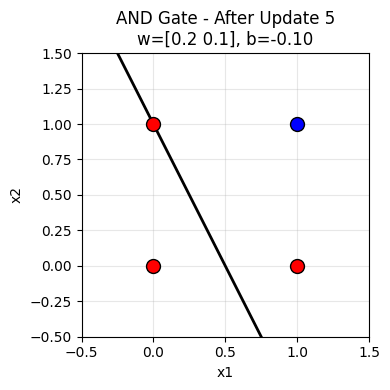

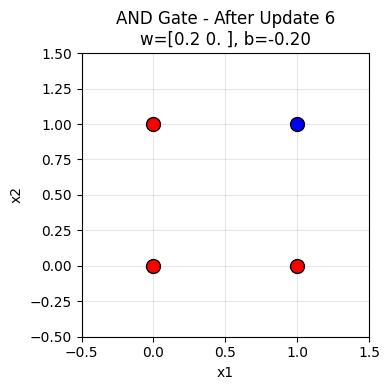

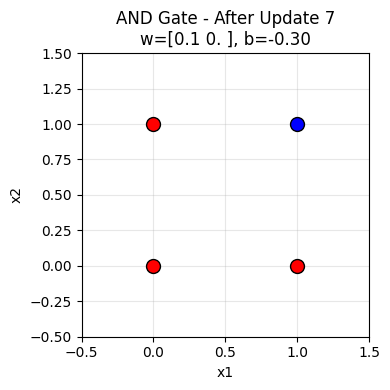

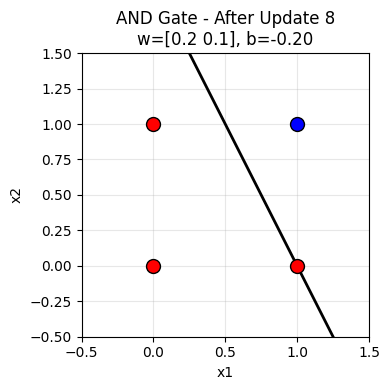

In [7]:
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])
print("AND GATE")
p_and = Perceptron(n_inputs=2, learning_rate=0.1)
p_and.train(X_and, y_and)

plot_decision_boundaries(p_and.weight_history, X_and, y_and, "AND")

OR GATE
Initial weights: [0. 0.], bias: 0.0

Update 1 (Epoch 1): input=[0 0], target=0, pred=1, weights=[0. 0.], bias=-0.10
Update 2 (Epoch 1): input=[0 1], target=1, pred=0, weights=[0.  0.1], bias=0.00
Update 3 (Epoch 2): input=[0 0], target=0, pred=1, weights=[0.  0.1], bias=-0.10
Update 4 (Epoch 2): input=[1 0], target=1, pred=0, weights=[0.1 0.1], bias=0.00
Update 5 (Epoch 3): input=[0 0], target=0, pred=1, weights=[0.1 0.1], bias=-0.10

Converged after epoch 4, total updates: 5


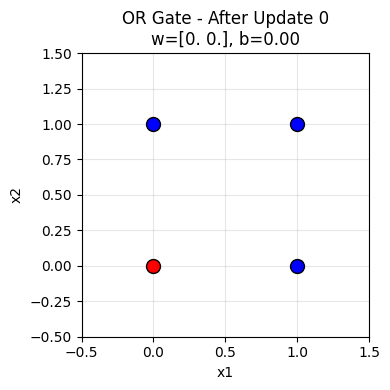

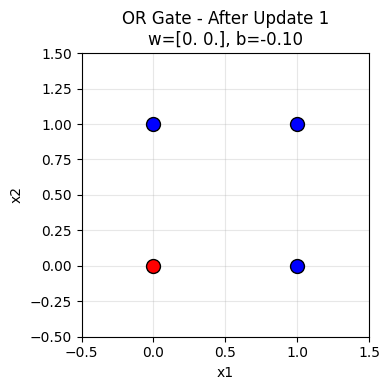

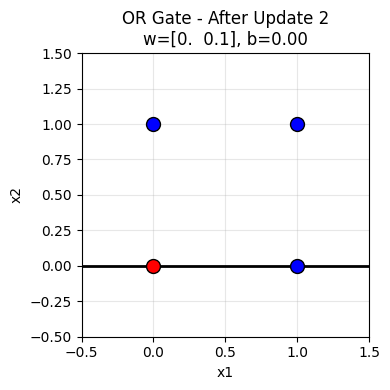

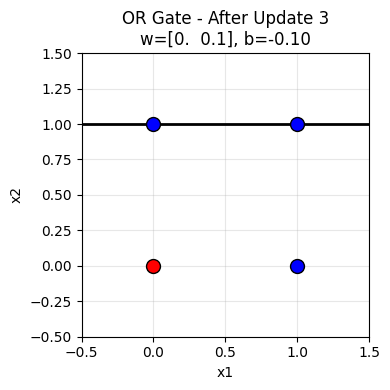

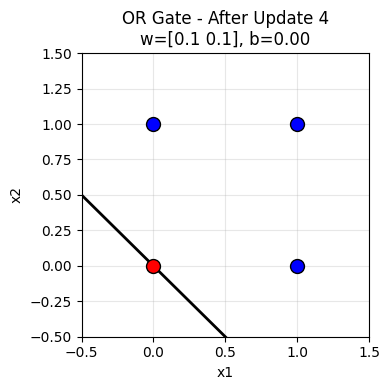

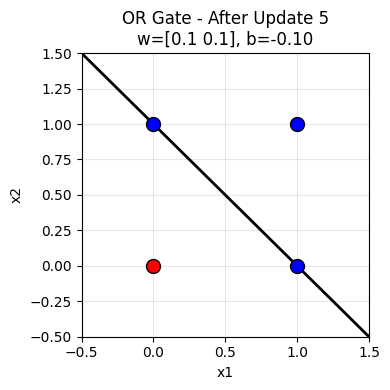

In [8]:
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or = np.array([0,1,1,1])
print("OR GATE")
p_or = Perceptron(n_inputs=2, learning_rate=0.1)
p_or.train(X_or, y_or)

plot_decision_boundaries(p_or.weight_history, X_or, y_or, "OR")

NOT GATE
Initial weights: [0.], bias: 0.0

Update 1 (Epoch 1): input=[1], target=0, pred=1, weights=[-0.1], bias=-0.10
Update 2 (Epoch 2): input=[0], target=1, pred=0, weights=[-0.1], bias=0.00

Converged after epoch 3, total updates: 2


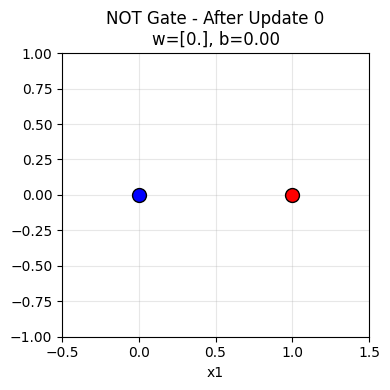

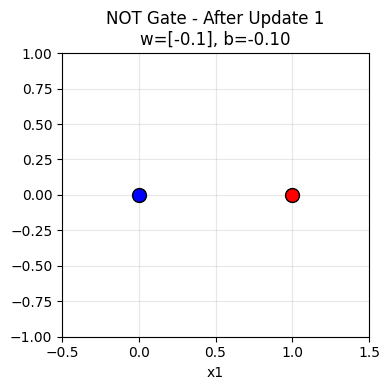

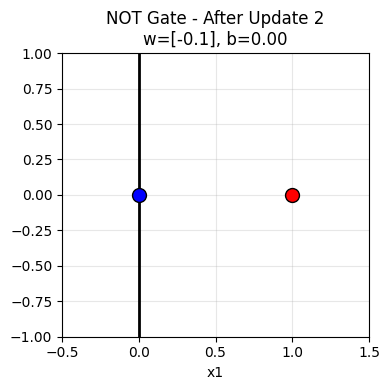

In [9]:
X_not = np.array([[0],[1]])
y_not = np.array([1,0])
print("NOT GATE")
p_not = Perceptron(n_inputs=1, learning_rate=0.1)
p_not.train(X_not, y_not)

plot_decision_boundaries(p_not.weight_history, X_not, y_not, "NOT")

XOR GATE (Single-Layer Perceptron)
Initial weights: [0. 0.], bias: 0.0

Update 1 (Epoch 1): input=[0 0], target=0, pred=1, weights=[0. 0.], bias=-0.10
Update 2 (Epoch 1): input=[0 1], target=1, pred=0, weights=[0.  0.1], bias=0.00
Update 3 (Epoch 1): input=[1 1], target=0, pred=1, weights=[-0.1  0. ], bias=-0.10
Update 4 (Epoch 2): input=[0 1], target=1, pred=0, weights=[-0.1  0.1], bias=0.00
Update 5 (Epoch 2): input=[1 0], target=1, pred=0, weights=[0.  0.1], bias=0.10
Update 6 (Epoch 2): input=[1 1], target=0, pred=1, weights=[-0.1  0. ], bias=0.00
Update 7 (Epoch 3): input=[0 0], target=0, pred=1, weights=[-0.1  0. ], bias=-0.10
Update 8 (Epoch 3): input=[0 1], target=1, pred=0, weights=[-0.1  0.1], bias=0.00
Update 9 (Epoch 3): input=[1 0], target=1, pred=0, weights=[0.  0.1], bias=0.10
Update 10 (Epoch 3): input=[1 1], target=0, pred=1, weights=[-0.1  0. ], bias=0.00
Update 11 (Epoch 4): input=[0 0], target=0, pred=1, weights=[-0.1  0. ], bias=-0.10
Update 12 (Epoch 4): input=[0 

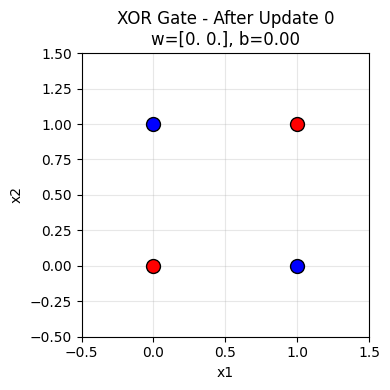

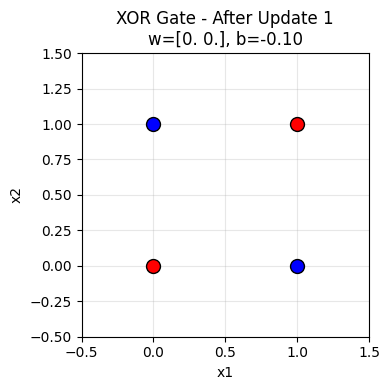

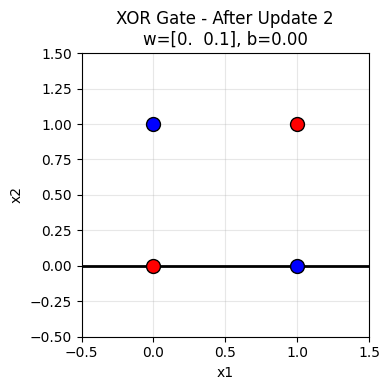

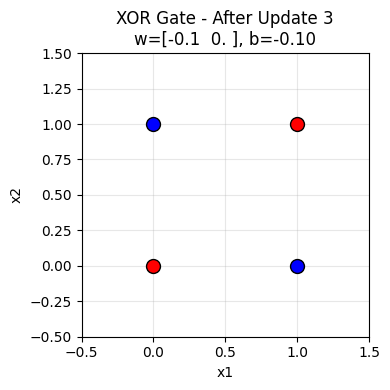

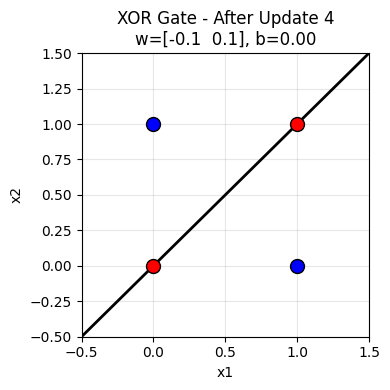

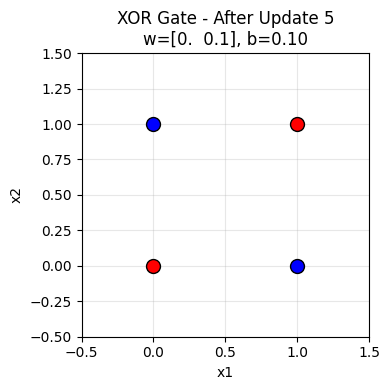

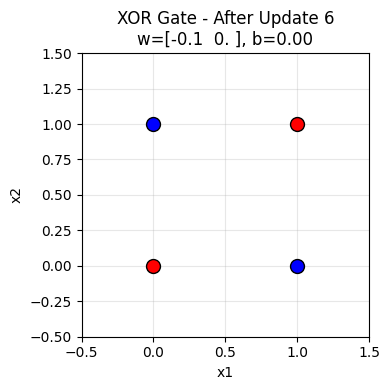

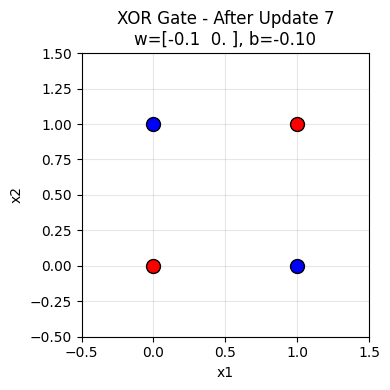

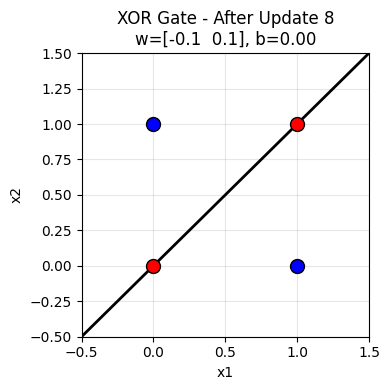

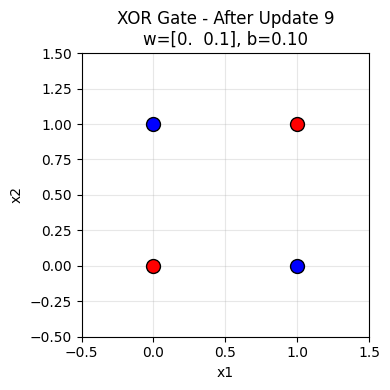

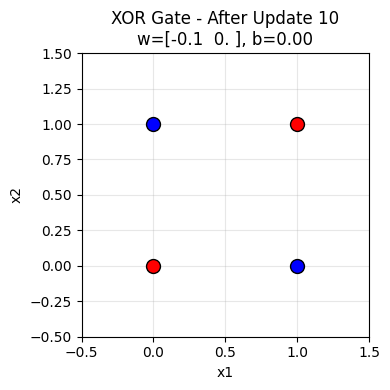

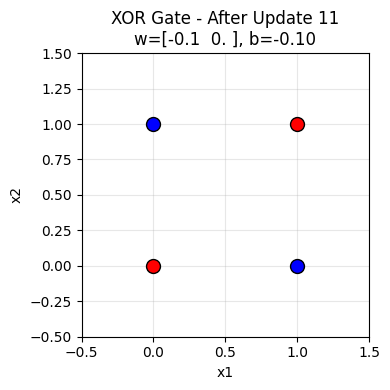

In [10]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])
print("XOR GATE (Single-Layer Perceptron)")
p_xor = Perceptron(n_inputs=2, learning_rate=0.1)
converged = p_xor.train(X_xor, y_xor, max_epochs=20)
plot_decision_boundaries(p_xor.weight_history, X_xor, y_xor, "XOR", max_plots=12)

In [11]:
class MLP:
    def __init__(self, n_input=2, n_hidden=2, n_output=1, learning_rate=0.5, seed=42):
        rng = np.random.default_rng(seed)
        self.W1 = rng.uniform(-1, 1, (n_input, n_hidden))
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.uniform(-1, 1, (n_hidden, n_output))
        self.b2 = np.zeros(n_output)
        self.lr = learning_rate
        self.weight_history = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_deriv(self, s):
        return s * (1 - s)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int).flatten()

    def train(self, X, y, epochs=10000, log_every=1000):
        y = y.reshape(-1, 1)

        for epoch in range(1, epochs + 1):

            output = self.forward(X)
            error = y - output
            d_output = error * self.sigmoid_deriv(output)

            error_hidden = d_output @ self.W2.T
            d_hidden = error_hidden * self.sigmoid_deriv(self.a1)

            self.W2 += self.lr * (self.a1.T @ d_output)
            self.b2 += self.lr * d_output.sum(axis=0)
            self.W1 += self.lr * (X.T @ d_hidden)
            self.b1 += self.lr * d_hidden.sum(axis=0)

            loss = np.mean(error ** 2)

            if epoch == 1 or epoch % log_every == 0:
                self.weight_history.append(
                    (epoch, self.W1.copy(), self.b1.copy(),
                     self.W2.copy(), self.b2.copy(), loss)
                )
                print(f"Epoch {epoch:5d} | Loss: {loss:.5f} | "
                      f"W1={np.round(self.W1,3).tolist()} b1={np.round(self.b1,3).tolist()} | "
                      f"W2={np.round(self.W2,3).tolist()} b2={np.round(self.b2,3).tolist()}")

            if loss < 1e-4:
                print(f"\nConverged at epoch {epoch}, loss={loss:.6f}")
                self.weight_history.append(
                    (epoch, self.W1.copy(), self.b1.copy(),
                     self.W2.copy(), self.b2.copy(), loss)
                )
                break

In [12]:
def plot_mlp_decision_boundary(mlp, W1, b1, W2, b2, X, y, epoch, loss):
    orig = (mlp.W1, mlp.b1, mlp.W2, mlp.b2)
    mlp.W1, mlp.b1, mlp.W2, mlp.b2 = W1, b1, W2, b2

    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = mlp.forward(grid).reshape(xx.shape)

    plt.figure(figsize=(4.5, 4.5))
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['#ffcccc', '#cce5ff'], alpha=0.7)
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

    for xi, target in zip(X, y):
        color = 'blue' if target == 1 else 'red'
        plt.scatter(xi[0], xi[1], c=color, s=100, edgecolors='black', zorder=3)

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f"XOR (MLP) - Epoch {epoch}\nLoss={loss:.4f}")
    plt.tight_layout()
    plt.show()

    mlp.W1, mlp.b1, mlp.W2, mlp.b2 = orig

In [15]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0,1,1,0], dtype=float)

print("XOR GATE (Multi-Layer Perceptron)")

mlp = MLP(n_input=2, n_hidden=2, n_output=1, learning_rate=0.5)
mlp.train(X_xor, y_xor, epochs=10000, log_every=1000)

print("\nFinal predictions:", mlp.predict(X_xor))
print("Expected:          ", y_xor.astype(int))

XOR GATE (Multi-Layer Perceptron)
Epoch     1 | Loss: 0.25164 | W1=[[0.544, -0.121], [0.714, 0.395]] b1=[-0.002, 0.0] | W2=[[-0.808], [0.952]] b2=[0.002]
Epoch  1000 | Loss: 0.17623 | W1=[[0.745, 3.15], [0.938, 3.227]] b1=[-0.7, -0.536] | W2=[[-2.1], [3.098]] b2=[-1.345]
Epoch  2000 | Loss: 0.00443 | W1=[[3.601, 5.546], [3.604, 5.561]] b1=[-5.52, -2.291] | W2=[[-7.758], [7.173]] b2=[-3.23]
Epoch  3000 | Loss: 0.00178 | W1=[[3.979, 5.854], [3.982, 5.865]] b1=[-6.11, -2.505] | W2=[[-8.641], [7.995]] b2=[-3.638]
Epoch  4000 | Loss: 0.00109 | W1=[[4.167, 6.013], [4.169, 6.022]] b1=[-6.4, -2.608] | W2=[[-9.103], [8.441]] b2=[-3.862]
Epoch  5000 | Loss: 0.00078 | W1=[[4.29, 6.119], [4.292, 6.127]] b1=[-6.589, -2.675] | W2=[[-9.416], [8.747]] b2=[-4.016]
Epoch  6000 | Loss: 0.00060 | W1=[[4.381, 6.198], [4.383, 6.205]] b1=[-6.728, -2.723] | W2=[[-9.652], [8.98]] b2=[-4.134]
Epoch  7000 | Loss: 0.00049 | W1=[[4.452, 6.26], [4.454, 6.267]] b1=[-6.837, -2.761] | W2=[[-9.841], [9.167]] b2=[-4.229

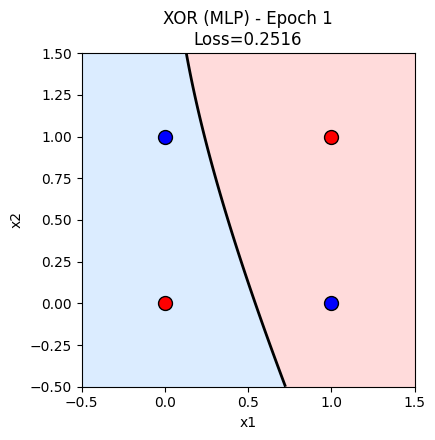

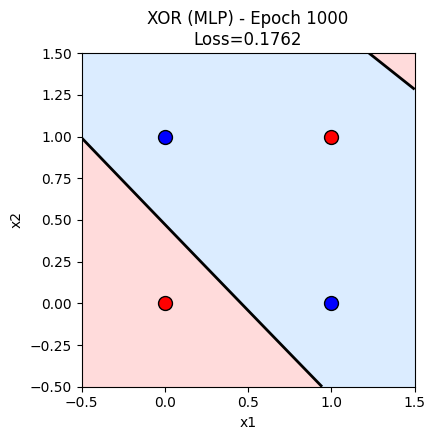

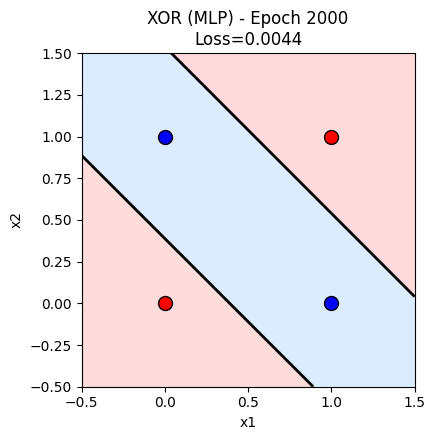

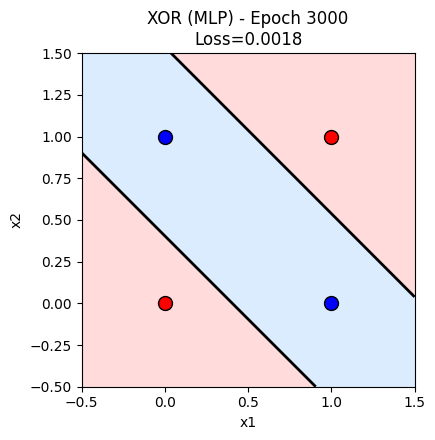

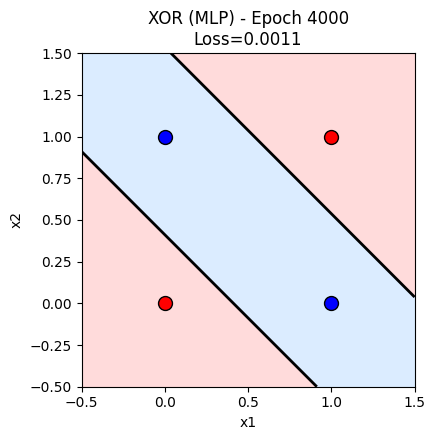

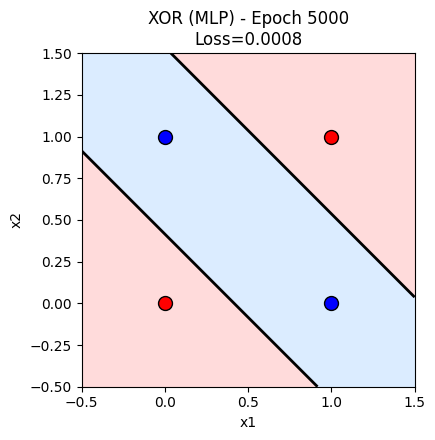

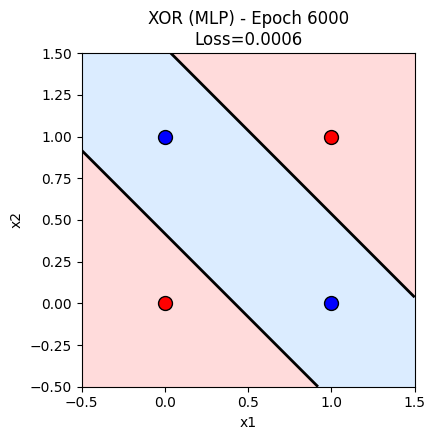

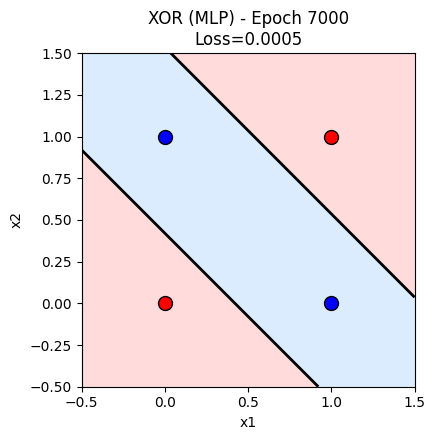

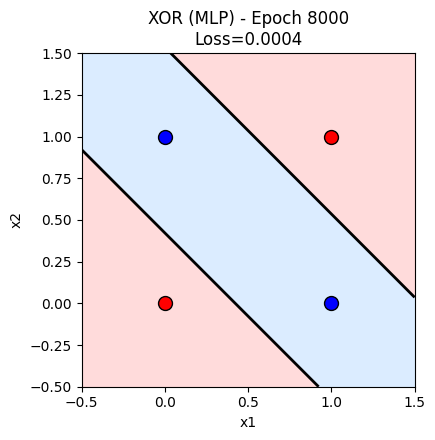

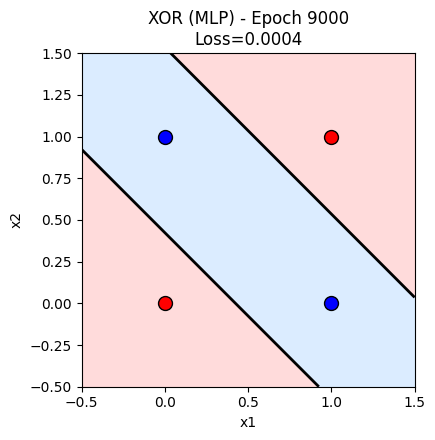

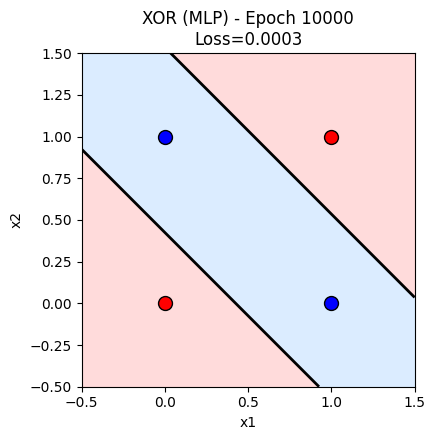

In [14]:
for epoch, W1, b1, W2, b2, loss in mlp.weight_history:
    plot_mlp_decision_boundary(mlp, W1, b1, W2, b2, X_xor, y_xor, epoch, loss)